# Ent. parametrization using moments

## Libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt

import pickle

import random_measurements as rm

# Deffinitions

In [2]:
d = 2

I = np.identity(d)

sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = 1j * np.array([[0, -1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

sigma = np.array([I, sigma_x, sigma_y, sigma_z])

psi_0 = np.array([[1], [0]])
psi_1 = np.array([[0], [1]])

# Functions

In [3]:
def combine_symmetric_pairs(original_dict):
    
    new_dict = {}
    
    for (p, q), value in original_dict.items():

        if (p, q) not in new_dict and (q, p) not in new_dict:

            new_dict[(p, q)] = value

        else:

            new_dict[(q, p)] += value
            
    return new_dict

def compute_beta_and_gamma(alpha):
    
    r = alpha.shape[0]
    
    beta = np.zeros((r, r))
    gamma = np.zeros((r, r))

    for k in range(r):
        
        for l in range(r):

            if k == l:

                beta[k, l] += alpha[k, k, k, k]

            elif k != l:
                
                beta[k, l] += alpha[k, k, l, l]
                
                beta[k, l] += alpha[k, l, l, k]
                
                gamma[k, l] += alpha[k, l, k, l]

    return beta, gamma

def dm_standard_form(sigma, d, N, r, phi):

    rho = np.zeros((r, r, d ** N, d ** N))
    T = np.zeros(tuple([r, r] + N * [d ** 2]), dtype = np.complex128)
    
    for i in range(r):
    
        for j in range(r):
    
            rho_ij = np.kron(phi[i], rm.adjoint(phi[j]))
            rho[i, j] = rho_ij
            
            T_ij = rm.correlation_tensor(sigma, d, N, rho_ij)
            T[i, j] = T_ij

    return rho, T

## $N = 2$

In [4]:
def compute_alpha_2(r, T, subsystem, display = False):
    
    alpha = np.zeros(tuple(4 * [r]))
    
    elements = 0
    
    for i1 in range(r):
        
        for j1 in range(r):
            
            for i2 in range(r):
                
                for j2 in range(r):

                    if subsystem == (1, 1):

                        a = np.sum((T[i1, j1][1:, 1:] * T[i2, j2][1:, 1:])).real

                    elif subsystem == (1, 0):

                        a = np.sum((T[i1, j1][1:, 0] * T[i2, j2][1:, 0])).real

                    elif subsystem == (0, 1):

                        a = np.sum((T[i1, j1][0, 1:] * T[i2, j2][0, 1:])).real

                    elif subsystem == (0, 0):

                        a = np.sum((T[i1, j1][0, 0] * T[i2, j2][0, 0])).real
                    
                    if a != 0:
                        
                        alpha[i1, j1, i2, j2] = a
                        elements += 1
                        
                        if display:

                            print(f"Indices: {i1 + 1, j1 + 1} {i2 + 1, j2 + 1} // {i1 + 1, i2 + 1} {j1 + 1, j2 + 1} - > ", a)

    return alpha, elements

In [5]:
N = 2

phi_1 = np.kron(psi_0, psi_0)
phi_2 = np.kron(psi_1, psi_1)

phi = np.array([phi_1, phi_2])
r = len(phi)

R, T = dm_standard_form(sigma, d, N, r, phi)

In [6]:
alpha, elements = compute_alpha_2(r, T, (1, 1))

print(f"\nNumber of elements: {elements}")

print("\nTensor of coefficients:\n")
print(alpha)

print("\nTensor of coefficients in lexicographic order:\n")
print(alpha.reshape((4, 4)))

beta, gamma = compute_beta_and_gamma(alpha)

print("\nReduced tensor of coefficients:")
print("\nBeta:\n")
print(beta)
print("\nGamma:\n")
print(gamma)

beta = np.triu(beta) + np.tril(beta, -1).T
gamma = np.triu(gamma) + np.tril(gamma, -1).T

print("\nReduced combined tensor of coefficients:")
print("\nBeta:\n")
print(beta)
print("\nGamma:\n")
print(gamma)

print("\nFor all real:\n")
print(beta + gamma)


Number of elements: 8

Tensor of coefficients:

[[[[1. 0.]
   [0. 1.]]

  [[0. 2.]
   [2. 0.]]]


 [[[0. 2.]
   [2. 0.]]

  [[1. 0.]
   [0. 1.]]]]

Tensor of coefficients in lexicographic order:

[[1. 0. 0. 1.]
 [0. 2. 2. 0.]
 [0. 2. 2. 0.]
 [1. 0. 0. 1.]]

Reduced tensor of coefficients:

Beta:

[[1. 3.]
 [3. 1.]]

Gamma:

[[0. 2.]
 [2. 0.]]

Reduced combined tensor of coefficients:

Beta:

[[1. 6.]
 [0. 1.]]

Gamma:

[[0. 4.]
 [0. 0.]]

For all real:

[[ 1. 10.]
 [ 0.  1.]]


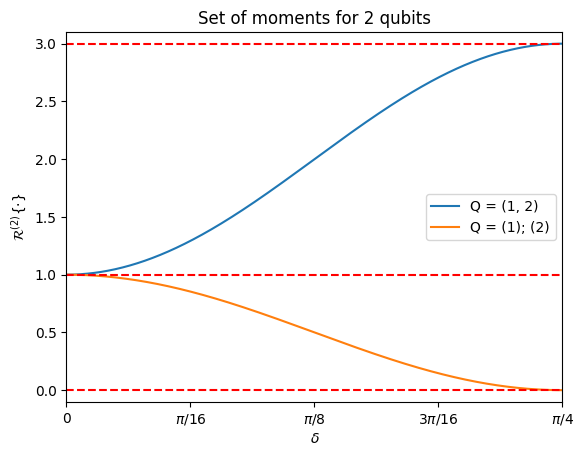

In [7]:
delta = np.linspace(0, np.pi / 4, 1000)

global_moment = 2 - np.cos(4 * delta)
marginal_moment = 0.5 * (1 + np.cos(4 * delta))

fig, ax = plt.subplots()

ax.plot(delta, global_moment, label = "Q = (1, 2)")
ax.plot(delta, marginal_moment, label = "Q = (1); (2)")

ax.axhline(y = 1, color = "r", linestyle = "--")
ax.axhline(y = 3, color = "r", linestyle = "--")
ax.axhline(y = 0, color = "r", linestyle = "--")

ax.set(title = "Set of moments for 2 qubits", xlabel = r"$\delta$", ylabel = r"$\mathcal{R}^{(2)} \{ \cdot \}$",
      xlim = (0, np.pi / 4), ylim = (-0.1, 3.1), xticks = np.arange(0, np.pi / 4 + 0.01, np.pi / 16),
      xticklabels = ['$0$', r'$\pi/16$', r'$\pi/8$', r'$3\pi/16$', r'$\pi / 4$'])

ax.legend()
plt.savefig("Set of moments for 2 qubits.jpg")
plt.show()

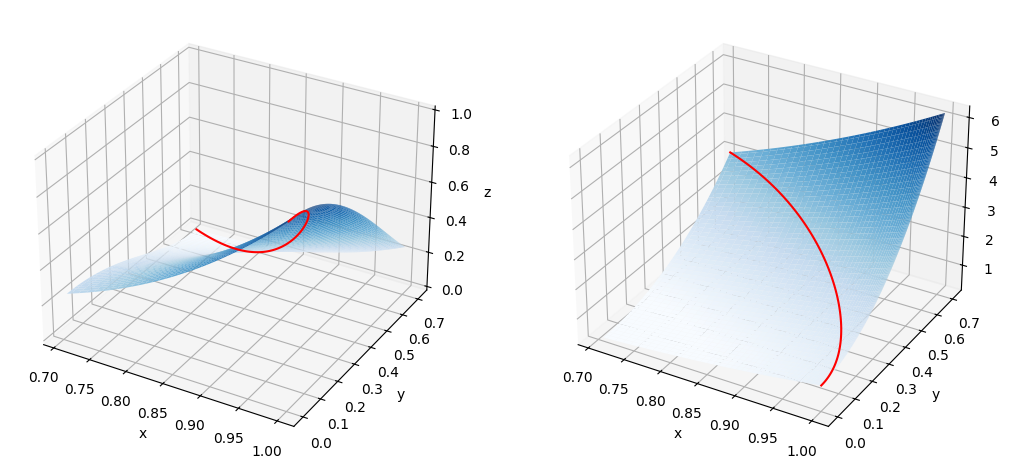

In [67]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('_mpl-gallery')

def two_qubit_moments(x, y):

    return ((x ** 2) - (y ** 2)) ** 2, (x ** 4) + (y ** 4) + 10 * (x ** 2) * (y ** 2) 

delta = np.linspace(0, np.pi / 4, 100)
x = np.cos(delta)
y = np.sin(delta)

X, Y = np.meshgrid(x, y)

z1, z12 = two_qubit_moments(x, y)

R1, R12 = two_qubit_moments(X, Y)

fig, ax = plt.subplots(1, 2, subplot_kw = {"projection": "3d"}, figsize = (10, 5))

ax[0].plot_surface(X, Y, R1, vmin = R1.min() * 2, cmap = cm.Blues)
ax[0].plot3D(x, y, z1, color = 'r')

ax[1].plot_surface(X, Y, R12, vmin = R12.min() * 2, cmap = cm.Blues)
ax[1].plot3D(x, y, z12, color = 'r')

ax[0].set_xlabel('x')
ax[1].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_ylabel('y')
ax[0].set_zlabel('z')
ax[1].set_zlabel('z')

plt.show()

## $N = 3$

In [8]:
N = 3

phi_1 = np.kron(np.kron(psi_0, psi_0), psi_0)
phi_2 = np.kron(np.kron(psi_0, psi_1), psi_1)
phi_3 = np.kron(np.kron(psi_1, psi_0), psi_1)
phi_4 = np.kron(np.kron(psi_1, psi_1), psi_0)
phi_5 = np.kron(np.kron(psi_1, psi_1), psi_1)

phi = np.array([phi_1, phi_2, phi_3, phi_4, phi_5])
r = len(phi)

rho, T = dm_standard_form(sigma, d, N, r, phi)

In [9]:
def compute_alpha_3(r, T, subsystem, display = False):
    
    alpha = np.zeros(tuple(4 * [r]))
    
    elements = 0
    
    for i1 in range(r):
        
        for j1 in range(r):
            
            for i2 in range(r):
                
                for j2 in range(r):

                    if subsystem == (1, 1, 1):

                        a = np.sum((T[i1, j1][1:, 1:, 1:] * T[i2, j2][1:, 1:, 1:])).real

                    elif subsystem == (1, 1, 0):

                        a = np.sum((T[i1, j1][1:, 1:, 0] * T[i2, j2][1:, 1:, 0])).real

                    elif subsystem == (1, 0, 1):

                        a = np.sum((T[i1, j1][1:, 0, 1:] * T[i2, j2][1:, 0, 1:])).real

                    elif subsystem == (0, 1, 1):

                        a = np.sum((T[i1, j1][0, 1:, 1:] * T[i2, j2][0, 1:, 1:])).real

                    elif subsystem == (1, 0, 0):

                        a = np.sum((T[i1, j1][1:, 0, 0] * T[i2, j2][1:, 0, 0])).real

                    elif subsystem == (0, 1, 0):

                        a = np.sum((T[i1, j1][0, 1:, 0] * T[i2, j2][0, 1:, 0])).real

                    elif subsystem == (0, 0, 1):

                        a = np.sum((T[i1, j1][0, 0, 1:] * T[i2, j2][0, 0, 1:])).real
                    
                    if a != 0:
                        
                        alpha[i1, j1, i2, j2] = a
                        elements += 1
                        
                        if display:

                            print(f"Indices: {i1 + 1, j1 + 1} {i2 + 1, j2 + 1} // {i1 + 1, i2 + 1} {j1 + 1, j2 + 1} - > ", a)

    return alpha, elements

In [10]:
alpha, elements = compute_alpha_3(r, T, (1, 1, 1))

print(f"\nNumber of elements: {elements}")


Number of elements: 65


In [11]:
beta, gamma = compute_beta_and_gamma(alpha)

print("\nReduced tensor of coefficients:")
print("\nBeta:\n")
print(beta)
print("\nGamma:\n")
print(gamma)

beta = np.triu(beta) + np.tril(beta, -1).T
gamma = np.triu(gamma) + np.tril(gamma, -1).T

print("\nReduced combined tensor of coefficients:")
print("\nBeta:\n")
print(beta)
print("\nGamma:\n")
print(gamma)

epsilon = np.copy(gamma)

k = 0
epsilon[k] = np.zeros(r)

print("\nReal/complex separation")
print("\nBeta:\n")
print(beta + epsilon)
print("\nGamma:\n")
print(gamma - epsilon)


Reduced tensor of coefficients:

Beta:

[[1. 3. 3. 3. 3.]
 [3. 1. 3. 3. 0.]
 [3. 3. 1. 3. 0.]
 [3. 3. 3. 1. 0.]
 [3. 0. 0. 0. 1.]]

Gamma:

[[0. 2. 2. 2. 4.]
 [2. 0. 2. 2. 1.]
 [2. 2. 0. 2. 1.]
 [2. 2. 2. 0. 1.]
 [4. 1. 1. 1. 0.]]

Reduced combined tensor of coefficients:

Beta:

[[1. 6. 6. 6. 6.]
 [0. 1. 6. 6. 0.]
 [0. 0. 1. 6. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

Gamma:

[[0. 4. 4. 4. 8.]
 [0. 0. 4. 4. 2.]
 [0. 0. 0. 4. 2.]
 [0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0.]]

Real/complex separation

Beta:

[[ 1.  6.  6.  6.  6.]
 [ 0.  1. 10. 10.  2.]
 [ 0.  0.  1. 10.  2.]
 [ 0.  0.  0.  1.  2.]
 [ 0.  0.  0.  0.  1.]]

Gamma:

[[0. 4. 4. 4. 8.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


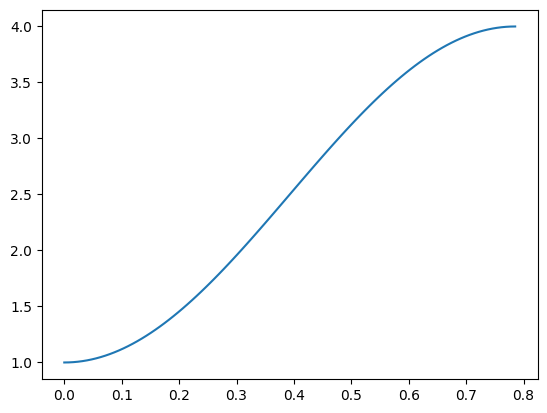

In [12]:
def R_GHZ(delta):

    return (beta + gamma)[0, 0] * ( np.cos(delta) ** 4 ) + (beta + gamma)[0, 4] * ( np.cos(delta) ** 2 ) * ( np.sin(delta) ** 2 ) + (beta + gamma)[4, 4] * ( np.sin(delta) ** 4 )

delta = np.linspace(0, np.pi / 4, 100)

R = R_GHZ(delta)

fig, ax = plt.subplots() 
ax.plot(delta, R)
plt.show()

In [31]:
partitions = [(1, 1, 1), (1, 1, 0), (1, 0, 1), (0, 1, 1), (1, 0, 0), (0, 1, 0), (0, 0, 1)]

beta = {}
gamma = {}

for p in partitions:

    alpha_p, _ = compute_alpha_3(r, T, p)
    
    beta_p, gamma_p = compute_beta_and_gamma(alpha_p)
    
    beta_p = np.triu(beta_p) + np.tril(beta_p, -1).T
    gamma_p = np.triu(gamma_p) + np.tril(gamma_p, -1).T
    
    epsilon_p = np.copy(gamma_p)
    k = 0
    epsilon_p[k] = np.zeros(r)

    beta[p] = beta_p + epsilon_p
    gamma[p] = gamma_p - epsilon_p

    print(f"\nPartition: {p}")
    print("\nBeta:\n")
    print(beta_p + epsilon_p)
    print("\nGamma:\n")
    print(gamma_p - epsilon_p)


Partition: (1, 1, 1)

Beta:

[[ 1.  6.  6.  6.  6.]
 [ 0.  1. 10. 10.  2.]
 [ 0.  0.  1. 10.  2.]
 [ 0.  0.  0.  1.  2.]
 [ 0.  0.  0.  0.  1.]]

Gamma:

[[0. 4. 4. 4. 8.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Partition: (1, 1, 0)

Beta:

[[ 1. -2. -2.  6.  2.]
 [ 0.  1. 10. -2.  2.]
 [ 0.  0.  1. -2.  2.]
 [ 0.  0.  0.  1.  2.]
 [ 0.  0.  0.  0.  1.]]

Gamma:

[[0. 0. 0. 4. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Partition: (1, 0, 1)

Beta:

[[ 1. -2.  6. -2.  2.]
 [ 0.  1. -2. 10.  2.]
 [ 0.  0.  1. -2.  2.]
 [ 0.  0.  0.  1.  2.]
 [ 0.  0.  0.  0.  1.]]

Gamma:

[[0. 0. 4. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Partition: (0, 1, 1)

Beta:

[[ 1.  6. -2. -2.  2.]
 [ 0.  1. -2. -2.  2.]
 [ 0.  0.  1. 10.  2.]
 [ 0.  0.  0.  1.  2.]
 [ 0.  0.  0.  0.  1.]]

Gamma:

[[0. 4. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Partition: (1, 

In [36]:
with open('beta', 'wb') as f:
    
    pickle.dump(beta, f)

with open('gamma', 'wb') as f:
    
    pickle.dump(gamma, f)

In [20]:
def f(beta, gamma, x):
    
    R = 0
    
    for i in range(1, gamma.shape[0]):

        R += gamma[0, i] * (x[i] ** 2)

    R *= (x[0] ** 2) * np.cos(2 * x[5])
    
    for i in range(beta.shape[0]):
        
        for j in range(beta.shape[1]):

            R += beta[i, j] * (x[i] ** 2) * (x[j] ** 2)
            
    return R

In [33]:
print(f(beta[(1, 1, 1)], gamma[(1, 1, 1)], (1 / np.sqrt(2), 0, 0, 0, 1 / np.sqrt(2), 0)))

3.9999999999999982


In [22]:
phi_0 = np.array([[1], [0]])
phi_1 = np.array([[0], [1]])
psi_0 = np.kron(np.kron(phi_0, phi_0), phi_0)
psi_1 = np.kron(np.kron(phi_1, phi_1), phi_1)

psi = (1 / np.sqrt(2)) * (psi_0 + psi_1)

rho = rm.pure_density_matrix(psi)

print(rm.moments(sigma, 2, 3, rho, approx = True))

{'000': 1.0, '100': 0.0, '010': 0.0, '001': 0.0, '110': 1.0, '101': 1.0, '011': 1.0, '111': 4.0}
